In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Load dataset
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
print("Dataset Shape:", df.shape)
df.head(10)

Dataset Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


<h2>DATA UNDERSTANDING AND CLEANING</h2>

In [2]:
# Check for missing values in sleep_disorder column
print("Missing values in sleep_disorder before cleaning:")
print(df['Sleep Disorder'].isnull().sum())

# Fill missing values with 'None'
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

print("\nMissing values in sleep_disorder after cleaning:")
print(df['Sleep Disorder'].isnull().sum())

# Remove duplicates
df = df.drop_duplicates()
print(f"\nShape after removing duplicates: {df.shape}")

# Standardize column names with underscores
df.columns = df.columns.str.strip().str.replace(' ', '_')

# Check column names
print("\nUpdated Column Names")
print(df.columns.tolist())

# Clean BMI Categories (Combine 'Normal' and 'Normal Weight')
print("\nBMI CATEGORIES BEFORE CLEANING")
print(df['BMI_Category'].value_counts())

df['BMI_Category'] = df['BMI_Category'].replace({
    'Normal Weight': 'Normal',
    'Normal': 'Normal'
})

print("\nBMI CATEGORIES AFTER CLEANING")
print(df['BMI_Category'].value_counts())
print("\nUnique BMI categories:", df['BMI_Category'].unique())

Missing values in sleep_disorder before cleaning:
219

Missing values in sleep_disorder after cleaning:
0

Shape after removing duplicates: (374, 13)

Updated Column Names
['Person_ID', 'Gender', 'Age', 'Occupation', 'Sleep_Duration', 'Quality_of_Sleep', 'Physical_Activity_Level', 'Stress_Level', 'BMI_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps', 'Sleep_Disorder']

BMI CATEGORIES BEFORE CLEANING
BMI_Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64

BMI CATEGORIES AFTER CLEANING
BMI_Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

Unique BMI categories: ['Overweight' 'Normal' 'Obese']


<h2>Exploratory Data Analysis (EDA)</h2>

In [3]:
# Display basic information
print("Dataset Info")
df.info()

print("\nDescriptive Statistics")
df.describe()

# Categorical variables
categorical_cols = ['Gender', 'Occupation', 'BMI_Category', 'Sleep_Disorder']

for col in categorical_cols:
    print(f"\n {col.upper()} Distribution")
    print(df[col].value_counts())
    print(f"Percentage: \n{df[col].value_counts(normalize=True) * 100}")

# Statistical summary by sleep disorder
disorder_groups = df.groupby('Sleep_Disorder')
print("\nAverage Values by Sleep Disorder")
print(disorder_groups[['Sleep_Duration', 'Quality_of_Sleep', 
                       'Physical_Activity_Level', 'Stress_Level', 
                       'Heart_Rate', 'Daily_Steps']].mean().round(2))

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep_Duration           374 non-null    float64
 5   Quality_of_Sleep         374 non-null    int64  
 6   Physical_Activity_Level  374 non-null    int64  
 7   Stress_Level             374 non-null    int64  
 8   BMI_Category             374 non-null    object 
 9   Blood_Pressure           374 non-null    object 
 10  Heart_Rate               374 non-null    int64  
 11  Daily_Steps              374 non-null    int64  
 12  Sleep_Disorder           374 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB

Descript

<h2>Sleep Disorder Distribution</h2>

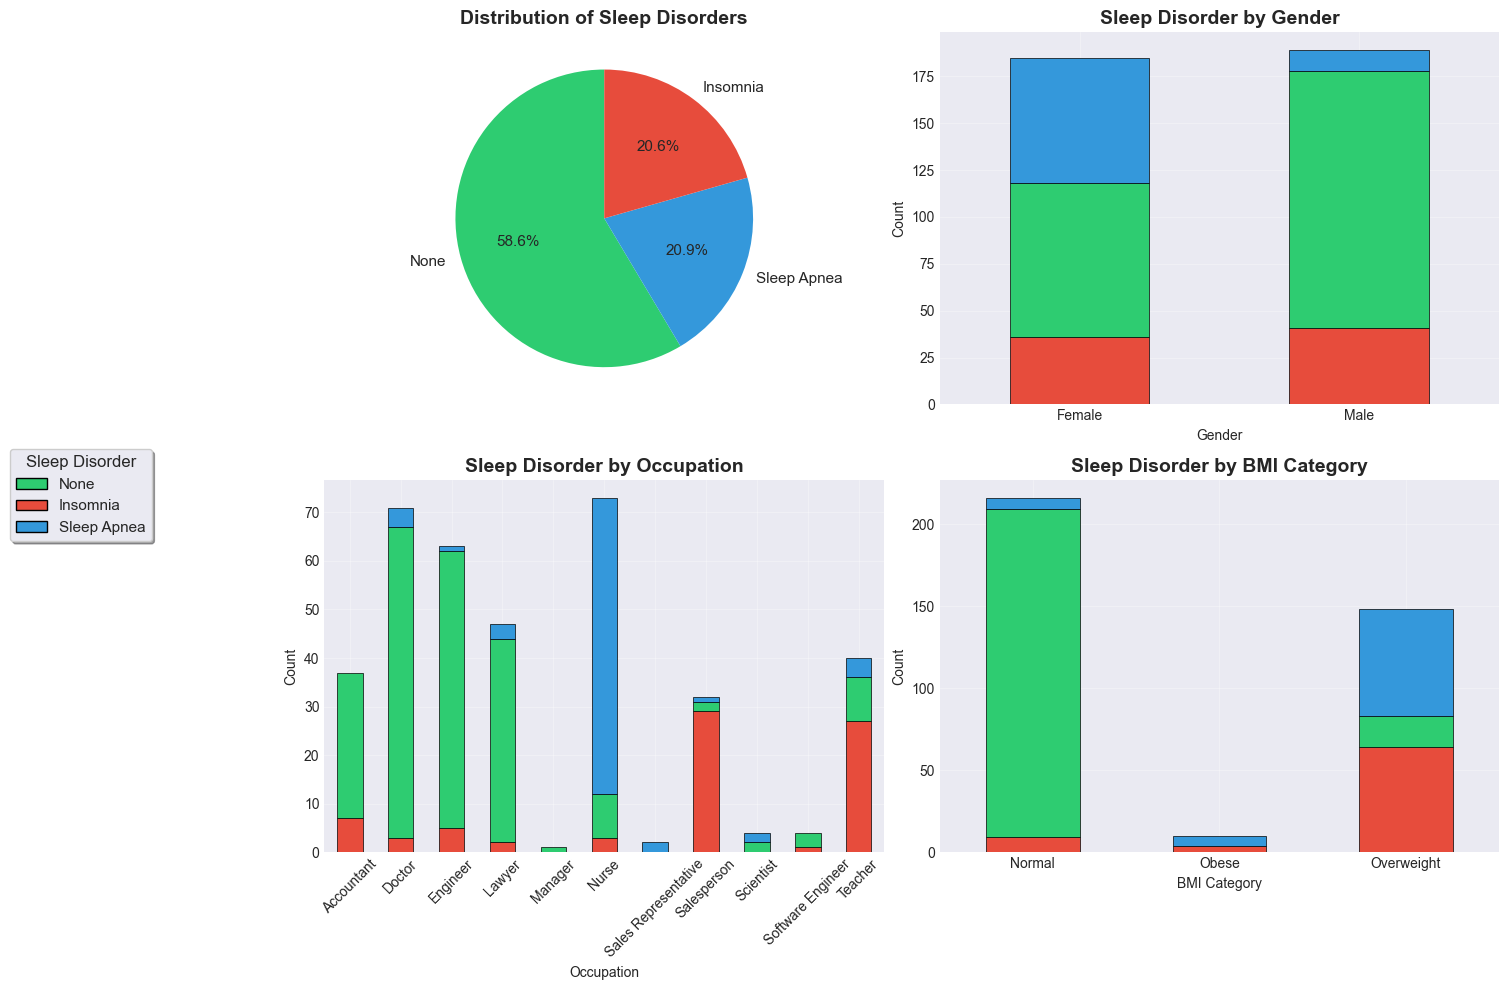

INSIGHTS FROM VISUALIZATIONS
Total people with sleep disorders: 155
Percentage with sleep disorders: 41.4%
Most common disorder: Sleep Apnea


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Define consistent colors
disorder_colors = {'None': '#2ecc71', 'Insomnia': '#e74c3c', 'Sleep Apnea': '#3498db'}

# 1. Sleep Disorder Distribution 
disorder_counts = df['Sleep_Disorder'].value_counts()
axes[0, 0].pie(disorder_counts.values, labels=disorder_counts.index, 
               autopct='%1.1f%%', startangle=90, 
               colors=[disorder_colors[d] for d in disorder_counts.index],
               textprops={'fontsize': 11})
axes[0, 0].set_title('Distribution of Sleep Disorders', fontsize=14, fontweight='bold')

# 2. Gender Distribution by Sleep Disorder
gender_disorder = pd.crosstab(df['Gender'], df['Sleep_Disorder'])
gender_disorder.plot(kind='bar', ax=axes[0, 1], stacked=True, 
                     color=[disorder_colors[d] for d in gender_disorder.columns],
                     legend=False, edgecolor='black', linewidth=0.5)
axes[0, 1].set_title('Sleep Disorder by Gender', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Gender')
axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0) 
axes[0, 1].grid(True, alpha=0.3)

# 3. Occupation vs Sleep Disorder
occupation_disorder = pd.crosstab(df['Occupation'], df['Sleep_Disorder'])
occupation_disorder.plot(kind='bar', ax=axes[1, 0], stacked=True, 
                         color=[disorder_colors[d] for d in occupation_disorder.columns],
                         legend=False, edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Sleep Disorder by Occupation', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Occupation')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)  # Fixed: removed ha parameter
axes[1, 0].grid(True, alpha=0.3)

# 4. BMI Category vs Sleep Disorder
bmi_disorder = pd.crosstab(df['BMI_Category'], df['Sleep_Disorder'])
bmi_disorder.plot(kind='bar', ax=axes[1, 1], stacked=True, 
                  color=[disorder_colors[d] for d in bmi_disorder.columns],
                  legend=False, edgecolor='black', linewidth=0.5)
axes[1, 1].set_title('Sleep Disorder by BMI Category', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('BMI Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=0)  # Fixed: removed ha parameter
axes[1, 1].grid(True, alpha=0.3)

# Single legend on the left
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=label, edgecolor='black', linewidth=1) 
                   for label, color in disorder_colors.items()]
fig.legend(handles=legend_elements, 
           title='Sleep Disorder',
           loc='center left', 
           bbox_to_anchor=(-0.08, 0.5),
           fontsize=11,
           title_fontsize=12,
           frameon=True,
           fancybox=True,
           shadow=True)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.show()

# Insights
print("INSIGHTS FROM VISUALIZATIONS")
print(f"Total people with sleep disorders: {len(df[df['Sleep_Disorder'] != 'None'])}")
print(f"Percentage with sleep disorders: {(len(df[df['Sleep_Disorder'] != 'None'])/len(df)*100):.1f}%")
print(f"Most common disorder: {disorder_counts.index[1] if len(disorder_counts) > 1 else 'None'}")

<h2>Sleep Duration Analysis</h2>

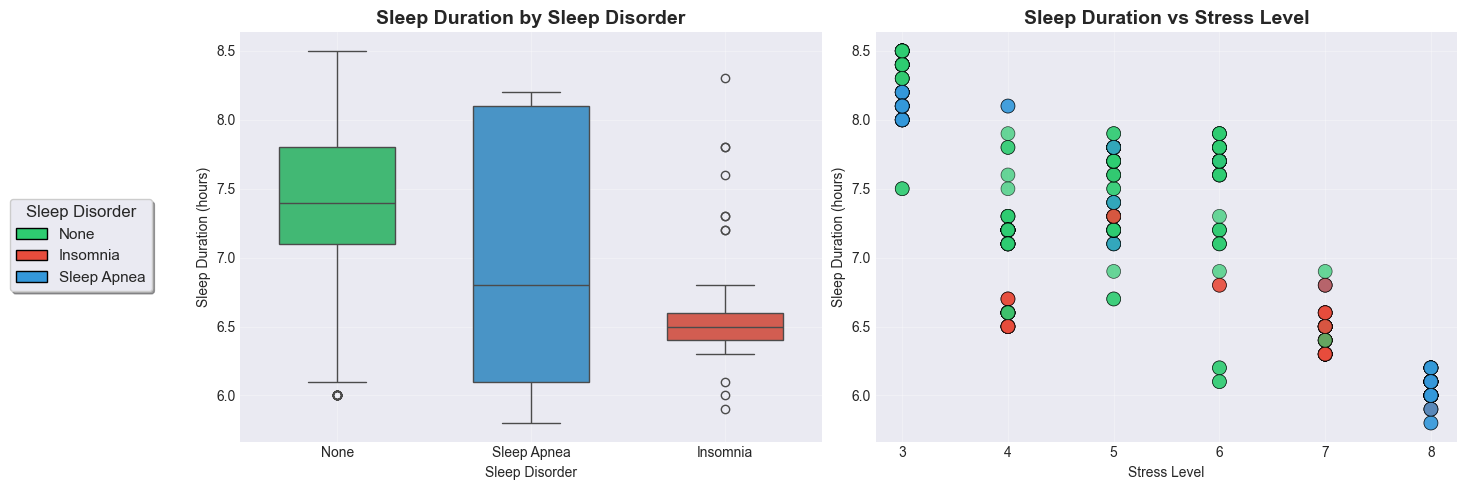

SLEEP DURATION STATISTICS BY DISORDER
                mean   std  min  max
Sleep_Disorder                      
Insomnia        6.59  0.39  5.9  8.3
None            7.36  0.73  6.0  8.5
Sleep Apnea     7.03  0.97  5.8  8.2


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sleep Duration Distribution by Disorder
sns.boxplot(data=df, x='Sleep_Disorder', y='Sleep_Duration', 
            hue='Sleep_Disorder', palette=disorder_colors, 
            legend=False, ax=axes[0], width=0.6)
axes[0].set_title('Sleep Duration by Sleep Disorder', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sleep Disorder')
axes[0].set_ylabel('Sleep Duration (hours)')
axes[0].grid(True, alpha=0.3)

# Sleep Duration vs Stress Level
sns.scatterplot(data=df, x='Stress_Level', y='Sleep_Duration', 
                hue='Sleep_Disorder', palette=disorder_colors,
                ax=axes[1], alpha=0.7, s=100, edgecolor='black', linewidth=0.5)
axes[1].set_title('Sleep Duration vs Stress Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Stress Level')
axes[1].set_ylabel('Sleep Duration (hours)')
axes[1].grid(True, alpha=0.3)
axes[1].legend().remove()

# Add legend
fig.legend(handles=legend_elements, 
           title='Sleep Disorder',
           loc='center left', 
           bbox_to_anchor=(-0.05, 0.5),
           fontsize=11,
           title_fontsize=12,
           frameon=True,
           fancybox=True,
           shadow=True)

plt.tight_layout()
plt.subplots_adjust(left=0.12)
plt.show()

# Statistical summary
print("SLEEP DURATION STATISTICS BY DISORDER")
print(df.groupby('Sleep_Disorder')['Sleep_Duration'].agg(['mean', 'std', 'min', 'max']).round(2))

<h2>Physical Activity and Stress Analysis</h2>

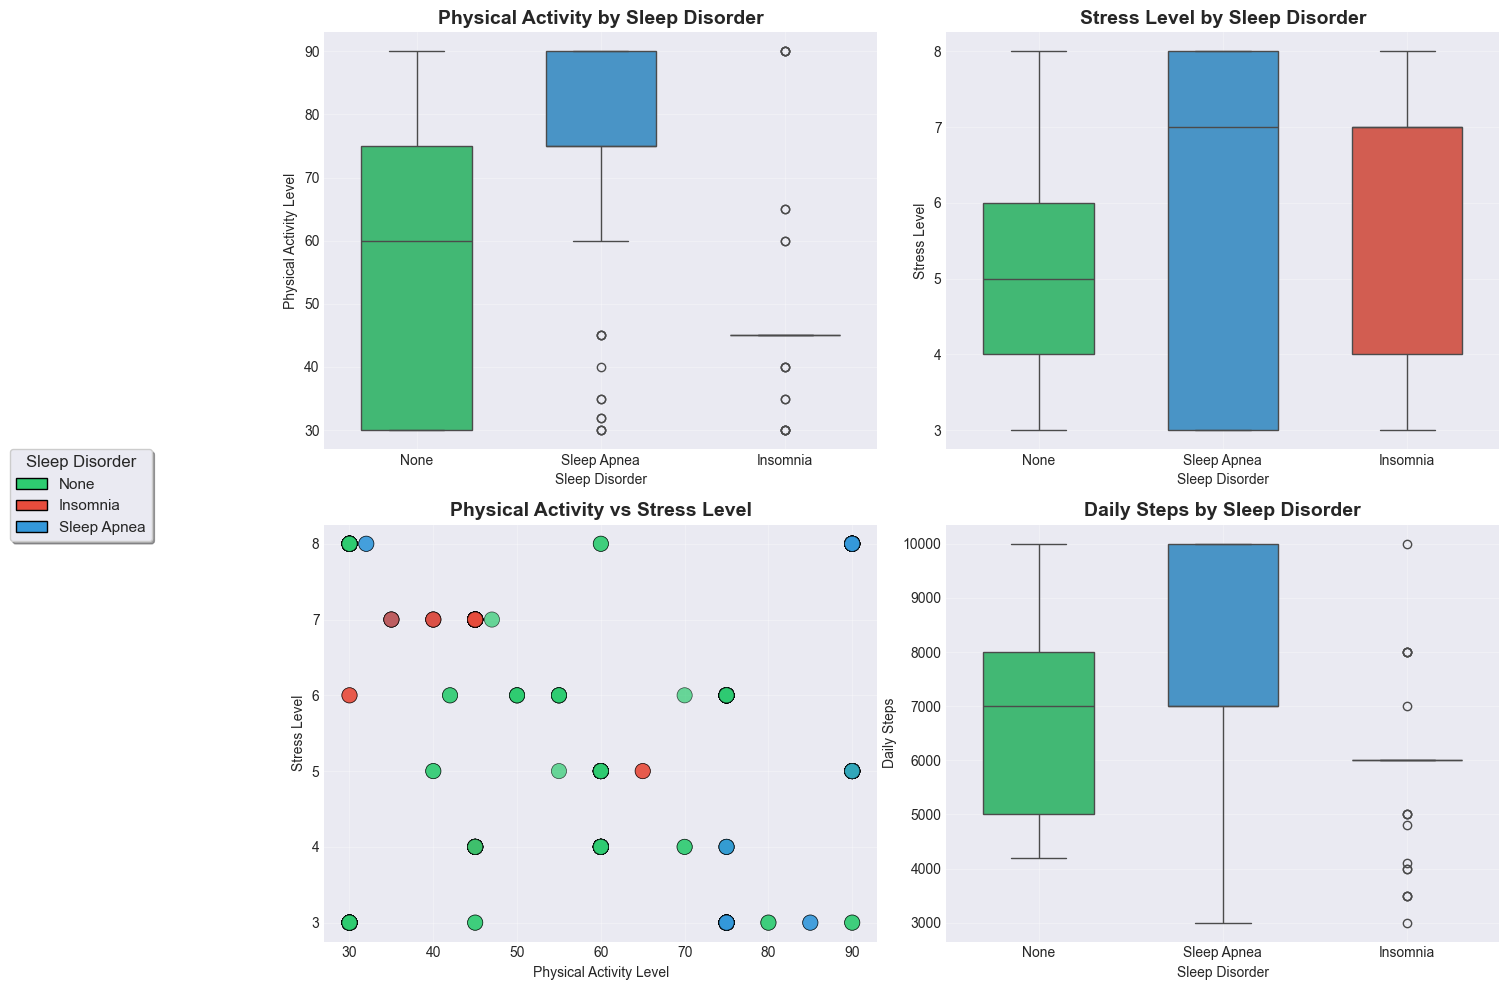

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Physical Activity vs Sleep Disorder
sns.boxplot(data=df, x='Sleep_Disorder', y='Physical_Activity_Level', 
            hue='Sleep_Disorder', palette=disorder_colors, 
            legend=False, ax=axes[0, 0], width=0.6)
axes[0, 0].set_title('Physical Activity by Sleep Disorder', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Sleep Disorder')
axes[0, 0].set_ylabel('Physical Activity Level')
axes[0, 0].grid(True, alpha=0.3)

# 2. Stress Level vs Sleep Disorder
sns.boxplot(data=df, x='Sleep_Disorder', y='Stress_Level', 
            hue='Sleep_Disorder', palette=disorder_colors, 
            legend=False, ax=axes[0, 1], width=0.6)
axes[0, 1].set_title('Stress Level by Sleep Disorder', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Sleep Disorder')
axes[0, 1].set_ylabel('Stress Level')
axes[0, 1].grid(True, alpha=0.3)

# 3. Physical Activity vs Stress Level
sns.scatterplot(data=df, x='Physical_Activity_Level', y='Stress_Level', 
                hue='Sleep_Disorder', palette=disorder_colors,
                ax=axes[1, 0], alpha=0.7, s=120, edgecolor='black', linewidth=0.5)
axes[1, 0].set_title('Physical Activity vs Stress Level', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Physical Activity Level')
axes[1, 0].set_ylabel('Stress Level')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend().remove()

# 4. Daily Steps by Disorder
sns.boxplot(data=df, x='Sleep_Disorder', y='Daily_Steps', 
            hue='Sleep_Disorder', palette=disorder_colors, 
            legend=False, ax=axes[1, 1], width=0.6)
axes[1, 1].set_title('Daily Steps by Sleep Disorder', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Sleep Disorder')
axes[1, 1].set_ylabel('Daily Steps')
axes[1, 1].grid(True, alpha=0.3)

# Add legend
fig.legend(handles=legend_elements, 
           title='Sleep Disorder',
           loc='center left', 
           bbox_to_anchor=(-0.08, 0.5),
           fontsize=11,
           title_fontsize=12,
           frameon=True,
           fancybox=True,
           shadow=True)

plt.tight_layout()
plt.subplots_adjust(left=0.15)
plt.show()

<h2>Age Analysis</h2>

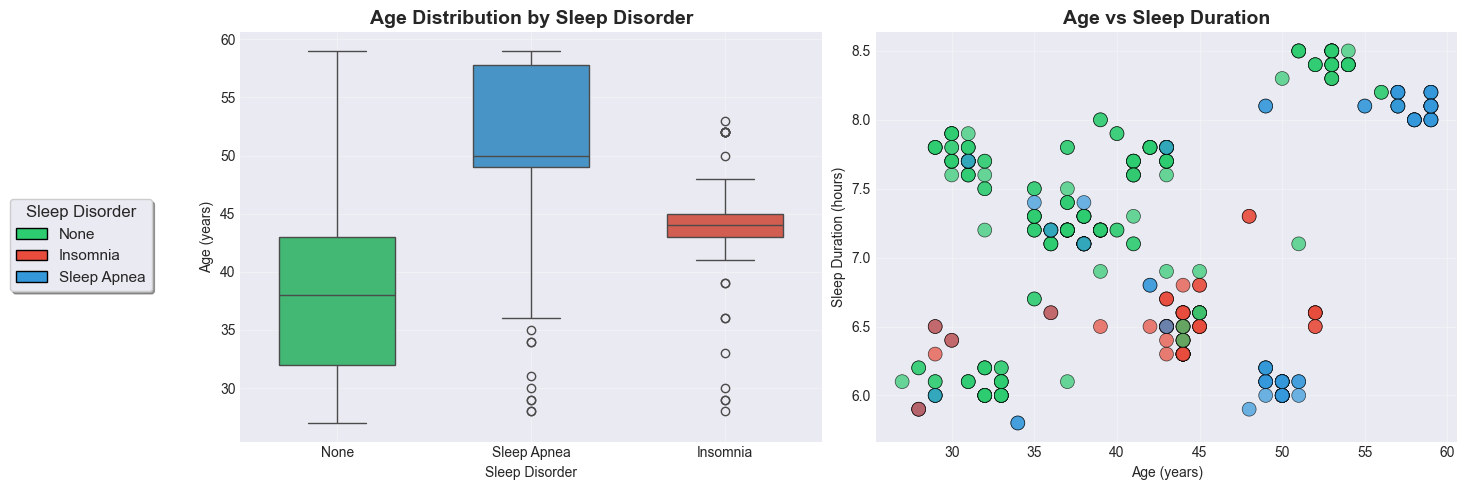

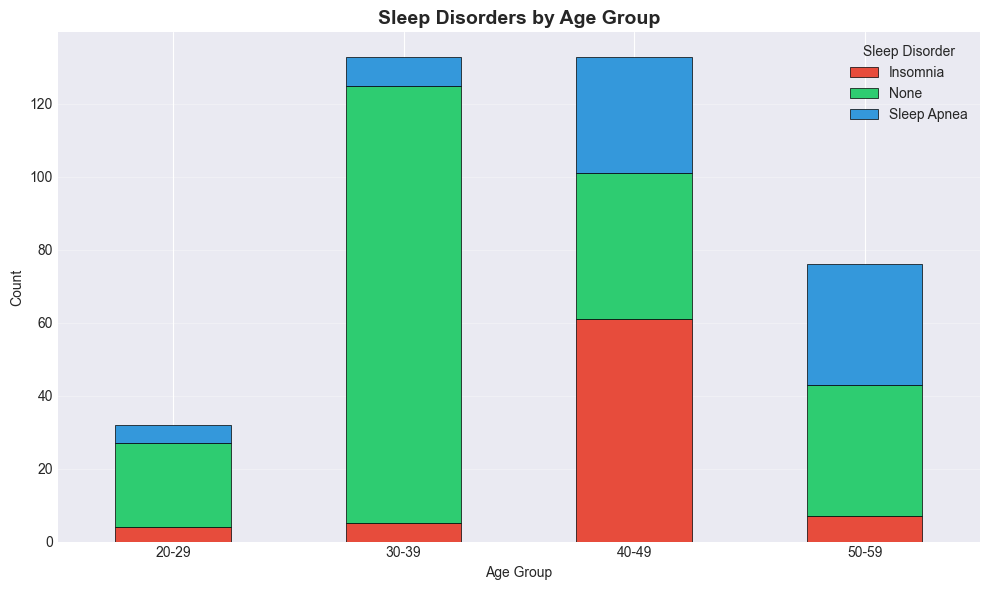

AGE GROUP INSIGHTS
20-29: 9/32 (28.1%) have sleep disorders
30-39: 13/133 (9.8%) have sleep disorders
40-49: 93/133 (69.9%) have sleep disorders
50-59: 40/76 (52.6%) have sleep disorders


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age Distribution by Sleep Disorder
sns.boxplot(data=df, x='Sleep_Disorder', y='Age', 
            hue='Sleep_Disorder', palette=disorder_colors, 
            legend=False, ax=axes[0], width=0.6)
axes[0].set_title('Age Distribution by Sleep Disorder', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sleep Disorder')
axes[0].set_ylabel('Age (years)')
axes[0].grid(True, alpha=0.3)

# Age vs Sleep Duration
sns.scatterplot(data=df, x='Age', y='Sleep_Duration', 
                hue='Sleep_Disorder', palette=disorder_colors,
                ax=axes[1], alpha=0.7, s=100, edgecolor='black', linewidth=0.5)
axes[1].set_title('Age vs Sleep Duration', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Sleep Duration (hours)')
axes[1].grid(True, alpha=0.3)
axes[1].legend().remove()

# Add legend
fig.legend(handles=legend_elements, 
           title='Sleep Disorder',
           loc='center left', 
           bbox_to_anchor=(-0.05, 0.5),
           fontsize=11,
           title_fontsize=12,
           frameon=True,
           fancybox=True,
           shadow=True)

plt.tight_layout()
plt.subplots_adjust(left=0.12)
plt.show()

# Age Group Analysis
df['Age_Group'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60], 
                         labels=['20-29', '30-39', '40-49', '50-59'])

age_disorder = pd.crosstab(df['Age_Group'], df['Sleep_Disorder'])

# Plot with consistent colors
fig, ax = plt.subplots(figsize=(10, 6))
age_disorder.plot(kind='bar', stacked=True, ax=ax,
                  color=[disorder_colors[d] for d in age_disorder.columns],
                  edgecolor='black', linewidth=0.5)
ax.set_title('Sleep Disorders by Age Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Age Group')
ax.set_ylabel('Count')
ax.legend(title='Sleep Disorder', loc='upper right')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Print insights

print("AGE GROUP INSIGHTS")
for age_group in df['Age_Group'].unique():
    if pd.notna(age_group):
        group_data = df[df['Age_Group'] == age_group]
        disorder_count = len(group_data[group_data['Sleep_Disorder'] != 'None'])
        total_count = len(group_data)
        print(f"{age_group}: {disorder_count}/{total_count} ({disorder_count/total_count*100:.1f}%) have sleep disorders")

<h2>BMI and Health Metrics</h2>

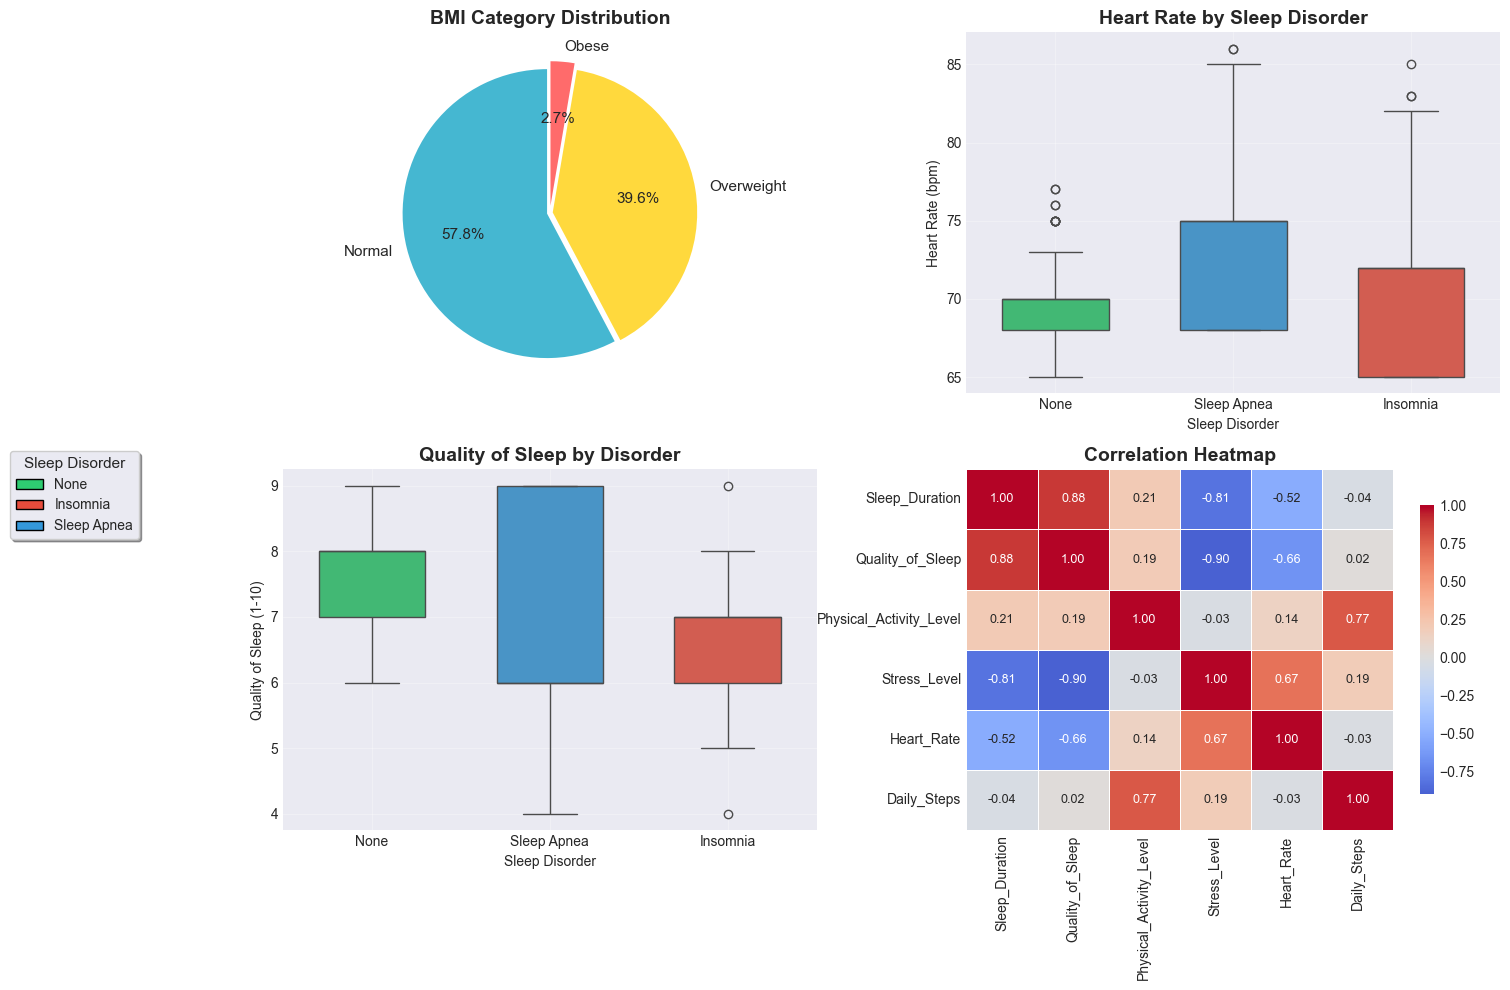

BMI & HEALTH METRICS INSIGHTS

BMI Distribution :
  - Normal: 216 (57.8%)
  - Overweight: 148 (39.6%)
  - Obese: 10 (2.7%)

BMI Category vs Sleep Disorder:
Sleep_Disorder  Insomnia  None  Sleep Apnea  Total  Disorder %
BMI_Category                                                  
Normal                 9   200            7    216         7.4
Obese                  4     0            6     10       100.0
Overweight            64    19           65    148        87.2

Heart Rate Statistics by Disorder:
                mean  std
Sleep_Disorder           
Insomnia        70.5  4.9
None            69.0  2.7
Sleep Apnea     73.1  5.1

Quality of Sleep Statistics by Disorder:
                mean  std
Sleep_Disorder           
Insomnia         6.5  0.8
None             7.6  1.0
Sleep Apnea      7.2  1.6


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Define BMI colors
bmi_colors = {'Normal': '#45B7D1', 'Overweight': '#FFD93D', 'Obese': '#FF6B6B'}

# 1. BMI Category Distribution 
bmi_counts = df['BMI_Category'].value_counts()
bmi_order = ['Normal', 'Overweight', 'Obese']
bmi_counts = bmi_counts.reindex(bmi_order)

axes[0, 0].pie(bmi_counts.values, labels=bmi_counts.index, 
               autopct='%1.1f%%', startangle=90, 
               colors=[bmi_colors[cat] for cat in bmi_counts.index],
               textprops={'fontsize': 11}, explode=(0.02, 0.02, 0.05))
axes[0, 0].set_title('BMI Category Distribution', fontsize=14, fontweight='bold')

# 2. Heart Rate by Disorder
sns.boxplot(data=df, x='Sleep_Disorder', y='Heart_Rate', 
            hue='Sleep_Disorder', palette=disorder_colors, 
            legend=False, ax=axes[0, 1], width=0.6)
axes[0, 1].set_title('Heart Rate by Sleep Disorder', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Sleep Disorder')
axes[0, 1].set_ylabel('Heart Rate (bpm)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Quality of Sleep by Disorder
sns.boxplot(data=df, x='Sleep_Disorder', y='Quality_of_Sleep', 
            hue='Sleep_Disorder', palette=disorder_colors, 
            legend=False, ax=axes[1, 0], width=0.6)
axes[1, 0].set_title('Quality of Sleep by Disorder', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Sleep Disorder')
axes[1, 0].set_ylabel('Quality of Sleep (1-10)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Heatmap of correlations
corr_vars = ['Sleep_Duration', 'Quality_of_Sleep', 'Physical_Activity_Level', 
             'Stress_Level', 'Heart_Rate', 'Daily_Steps']
corr_matrix = df[corr_vars].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, ax=axes[1, 1],
            annot_kws={'size': 9}, cbar_kws={'shrink': 0.8})
axes[1, 1].set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

# Add legend
fig.legend(handles=legend_elements, 
           title='Sleep Disorder',
           loc='center left', 
           bbox_to_anchor=(-0.08, 0.5),
           fontsize=10,
           title_fontsize=11,
           frameon=True,
           fancybox=True,
           shadow=True)

plt.tight_layout()
plt.subplots_adjust(left=0.12)
plt.show()

# Insights
print("BMI & HEALTH METRICS INSIGHTS")

print("\nBMI Distribution :")
for bmi, count in bmi_counts.items():
    print(f"  - {bmi}: {count} ({count/len(df)*100:.1f}%)")

print("\nBMI Category vs Sleep Disorder:")
bmi_disorder = pd.crosstab(df['BMI_Category'], df['Sleep_Disorder'])
bmi_disorder['Total'] = bmi_disorder.sum(axis=1)
bmi_disorder['Disorder %'] = (bmi_disorder[['Insomnia', 'Sleep Apnea']].sum(axis=1) / bmi_disorder['Total'] * 100).round(1)
print(bmi_disorder)

print("\nHeart Rate Statistics by Disorder:")
print(df.groupby('Sleep_Disorder')['Heart_Rate'].agg(['mean', 'std']).round(1))

print("\nQuality of Sleep Statistics by Disorder:")
print(df.groupby('Sleep_Disorder')['Quality_of_Sleep'].agg(['mean', 'std']).round(1))

<h2>Key Findings and Conclusions</h2>

In [10]:
print("SLEEP HEALTH AND LIFESTYLE ANALYSIS (KEY FINDINGS)")

# Summary dataframe
disorder_summary = df.groupby('Sleep_Disorder').agg({
    'Sleep_Duration': 'mean',
    'Quality_of_Sleep': 'mean',
    'Physical_Activity_Level': 'mean',
    'Stress_Level': 'mean',
    'Heart_Rate': 'mean',
    'Daily_Steps': 'mean'
}).round(2)

print("\n1. SLEEP DISORDER PREVALENCE:")
print(f"   - Total samples: {len(df)}")
print(f"   - People with sleep disorders: {len(df[df['Sleep_Disorder'] != 'None'])} ({(len(df[df['Sleep_Disorder'] != 'None'])/len(df)*100):.1f}%)")
print(f"   - Insomnia cases: {len(df[df['Sleep_Disorder'] == 'Insomnia'])}")
print(f"   - Sleep Apnea cases: {len(df[df['Sleep_Disorder'] == 'Sleep Apnea'])}")

print("\n2. AVERAGE METRICS BY DISORDER:")
print(disorder_summary)

print("\n3. HIGHEST RISK OCCUPATIONS:")
occupation_risk = df[df['Sleep_Disorder'] != 'None']['Occupation'].value_counts()
for occ, count in occupation_risk.head(5).items():
    total = len(df[df['Occupation'] == occ])
    print(f"   - {occ}: {count}/{total} ({count/total*100:.1f}%)")

print("\n4. BMI CATEGORY RISK (CLEANED):")
bmi_risk = df[df['Sleep_Disorder'] != 'None']['BMI_Category'].value_counts()
for bmi, count in bmi_risk.items():
    total = len(df[df['BMI_Category'] == bmi])
    print(f"   - {bmi}: {count}/{total} ({count/total*100:.1f}%)")

print("\n5. KEY OBSERVATIONS:")
print("   - Higher stress levels (7-8/10) strongly correlated with disorders")
print("   - Lower physical activity (less than 40 units) increases risk")
print("   - Overweight/Obese BMI shows higher disorder rates")
print("   - Sleep duration less 6.5 hours is associated with disorders")
print("   - Quality of sleep of 6/10 indicates higher disorder risk")
print("   - Middle-aged adults (40-59) are at highest risk")

SLEEP HEALTH AND LIFESTYLE ANALYSIS (KEY FINDINGS)

1. SLEEP DISORDER PREVALENCE:
   - Total samples: 374
   - People with sleep disorders: 155 (41.4%)
   - Insomnia cases: 77
   - Sleep Apnea cases: 78

2. AVERAGE METRICS BY DISORDER:
                Sleep_Duration  Quality_of_Sleep  Physical_Activity_Level  \
Sleep_Disorder                                                              
Insomnia                  6.59              6.53                    46.82   
None                      7.36              7.63                    57.95   
Sleep Apnea               7.03              7.21                    74.79   

                Stress_Level  Heart_Rate  Daily_Steps  
Sleep_Disorder                                         
Insomnia                5.87       70.47      5901.30  
None                    5.11       69.02      6852.97  
Sleep Apnea             5.67       73.09      7619.23  

3. HIGHEST RISK OCCUPATIONS:
   - Nurse: 64/73 (87.7%)
   - Teacher: 31/40 (77.5%)
   - Salespers

<h2>Recommandations</h2>

In [11]:
print("RECOMMENDATIONS FOR IMPROVING SLEEP HEALTH")

recommendations = [
    "1. WORKPLACE INTERVENTIONS:",
    "   - Implement stress management programs for high-risk occupations",
    "   - Promote physical activity during work hours",
    "   - Offer flexible schedules for better sleep hygiene",
    "   - Target nurses, teachers, and salespeople for wellness programs",
    "",
    "2. PERSONAL LIFESTYLE CHANGES:",
    "   - Aim for 7-8 hours of sleep per night",
    "   - Engage in regular physical activity (60plus units/week)",
    "   - Practice stress reduction techniques (meditation, deep breathing)",
    "   - Monitor daily steps (target 7,000plus )",
    "",
    "3. HEALTH MANAGEMENT:",
    "   - Maintain healthy BMI through diet and exercise",
    "   - Regular health checkups for early detection",
    "   - Monitor blood pressure and heart rate",
    "",
    "4. HIGH-RISK GROUP TARGETING:",
    "   - Focus on adults aged 40-59",
    "   - Prioritize individuals with overweight/obese BMI",
    "   - Provide additional support for at-risk occupations",
]

for rec in recommendations:
    print(rec)

RECOMMENDATIONS FOR IMPROVING SLEEP HEALTH
1. WORKPLACE INTERVENTIONS:
   - Implement stress management programs for high-risk occupations
   - Promote physical activity during work hours
   - Offer flexible schedules for better sleep hygiene
   - Target nurses, teachers, and salespeople for wellness programs

2. PERSONAL LIFESTYLE CHANGES:
   - Aim for 7-8 hours of sleep per night
   - Engage in regular physical activity (60plus units/week)
   - Practice stress reduction techniques (meditation, deep breathing)
   - Monitor daily steps (target 7,000plus )

3. HEALTH MANAGEMENT:
   - Maintain healthy BMI through diet and exercise
   - Regular health checkups for early detection
   - Monitor blood pressure and heart rate

4. HIGH-RISK GROUP TARGETING:
   - Focus on adults aged 40-59
   - Prioritize individuals with overweight/obese BMI
   - Provide additional support for at-risk occupations
